In [6]:
import pandas as pd


In [7]:
data = {
    'Country':     ['Afghanistan','Bangladesh','Pakistan','Nepal','Maldives','India','Sri Lanka','Bhutan'],
    'ND_GAIN':     [33.2, 35.5, 39.2, 43.6, 45.2, 45.5, 45.5, 48.2],
    'Vulnerability':[0.588, 0.568, 0.515, 0.490, 0.550, 0.485, 0.475, 0.515],
    'RE_Pct':      [78.23, 1.51, 28.28, 83.98, 5.82, 51.50, 49.24, 100.00],
    'WGI_Score':   [13.74, 39.31, 39.67, 34.14, 47.04, 59.21, 46.00, 62.63],
    'EPI_Score':   [31.0, 28.1, 25.5, 33.1, 38.1, 27.6, 38.8, 43.3],
    'EPI_Rank':    [171, 175, 179, 165, 138, 176, 134, 103]
}

df = pd.DataFrame(data)
print(df)

       Country  ND_GAIN  Vulnerability  RE_Pct  WGI_Score  EPI_Score  EPI_Rank
0  Afghanistan     33.2          0.588   78.23      13.74       31.0       171
1   Bangladesh     35.5          0.568    1.51      39.31       28.1       175
2     Pakistan     39.2          0.515   28.28      39.67       25.5       179
3        Nepal     43.6          0.490   83.98      34.14       33.1       165
4     Maldives     45.2          0.550    5.82      47.04       38.1       138
5        India     45.5          0.485   51.50      59.21       27.6       176
6    Sri Lanka     45.5          0.475   49.24      46.00       38.8       134
7       Bhutan     48.2          0.515  100.00      62.63       43.3       103


In [8]:
import plotly.express as px

fig = px.bar(df.sort_values('EPI_Score'),
             x='Country',
             y='EPI_Score',
             title='South Asia Environmental Performance Index 2024',
             labels={'EPI_Score': 'EPI Score (0-100)'})
fig.show()


In [10]:

df.to_csv('south_asia_monitor.csv', index=False)
print("Saved!")

Saved!


In [11]:
fig2 = px.bar(df.sort_values('ND_GAIN'),
              x='Country',
              y='ND_GAIN',
              title='Climate Vulnerability — ND-GAIN Scores (Higher = Better Adapted)',
              labels={'ND_GAIN': 'ND-GAIN Score'},
              color='ND_GAIN',
              color_continuous_scale='RdYlGn')
fig2.show()

In [12]:
fig3 = px.bar(df.sort_values('RE_Pct'),
              x='Country',
              y='RE_Pct',
              title='Renewable Electricity % — South Asia (World Bank 2021, India updated 2025)',
              labels={'RE_Pct': 'RE % of Electricity Output'},
              color='RE_Pct',
              color_continuous_scale='Greens')
fig3.show()

In [13]:
fig4 = px.scatter(df,
                  x='Vulnerability',
                  y='WGI_Score',
                  text='Country',
                  size='EPI_Score',
                  color='EPI_Score',
                  color_continuous_scale='RdYlGn',
                  title='Governance Quality vs Climate Vulnerability — South Asia',
                  labels={'Vulnerability': 'Climate Vulnerability (ND-GAIN)',
                          'WGI_Score': 'Governance Score (WGI 0-100)'})
fig4.update_traces(textposition='top center')
fig4.show()


In [14]:
df.to_csv('south_asia_climate_geo_monitor.csv', index=False)

# Save all 4 charts as HTML (interactive, shareable)
fig.write_html('chart1_epi.html')
fig2.write_html('chart2_ndgain.html')
fig3.write_html('chart3_re.html')
fig4.write_html('chart4_scatter.html')

print("All files saved!")

All files saved!


In [15]:
# CHART 5 — Fiscal Stress (VERIFIED FIGURES ONLY)
# Afghanistan: Afghanistan MoF/SIPRI 2021 — last available pre-Taliban
# Maldives: IMF Article IV Consultation 2024 (direct citation)
# Sri Lanka: CBSL Annual Economic Review 2024 (direct citation)
# All others: IMF WEO 2026

df['Fiscal_Balance'] = [-2.3, -4.3, -3.2, -2.5, -12.2, -7.4, -6.8, -2.9]
df['Fiscal_Source'] = [
    'Afghanistan MoF/SIPRI 2021 — last pre-Taliban data',
    'IMF WEO 2026',
    'IMF WEO 2026',
    'IMF WEO 2026',
    'IMF Article IV Consultation 2024',
    'IMF WEO 2026',
    'CBSL Annual Economic Review 2024',
    'IMF WEO 2026'
]

fig5 = px.bar(df.sort_values('Fiscal_Balance'),
              x='Country',
              y='Fiscal_Balance',
              title='Fiscal Stress — South Asia (IMF WEO 2026 + Verified Sources)<br><sup>Maldives most stressed at -12.2% | Sri Lanka recovering at -6.8% under IMF EFF</sup>',
              labels={'Fiscal_Balance': 'Fiscal Balance (% of GDP)'},
              color='Fiscal_Balance',
              color_continuous_scale='RdYlGn',
              hover_data=['Fiscal_Source'])

fig5.add_hline(y=-5, line_dash='dot', line_color='red',
               annotation_text='High stress threshold (-5%)')
fig5.add_hline(y=-10, line_dash='dot', line_color='darkred',
               annotation_text='Crisis threshold (-10%)')
fig5.update_traces(cliponaxis=False)
fig5.write_html('chart5_fiscal_final.html')
fig5.show()
print("✅ Chart 5 done — all 8 countries, all sources verified")

✅ Chart 5 done — all 8 countries, all sources verified


In [16]:
# Save final dataset and all charts
df.to_csv('south_asia_monitor_FINAL.csv', index=False)
fig.write_html('chart1_epi_final.html')
fig2.write_html('chart2_ndgain_final.html')
fig3.write_html('chart3_re_final.html')
fig4.write_html('chart4_scatter_final.html')
fig5.write_html('chart5_fiscal_final.html')

print("✅ SOUTH ASIA CLIMATE-GEOPOLITICAL RISK MONITOR — COMPLETE")
print("Files saved:")
for f in ['chart1_epi_final.html','chart2_ndgain_final.html',
          'chart3_re_final.html','chart4_scatter_final.html',
          'chart5_fiscal_final.html','south_asia_monitor_FINAL.csv']:
    print(f"  → {f}")



✅ SOUTH ASIA CLIMATE-GEOPOLITICAL RISK MONITOR — COMPLETE
Files saved:
  → chart1_epi_final.html
  → chart2_ndgain_final.html
  → chart3_re_final.html
  → chart4_scatter_final.html
  → chart5_fiscal_final.html
  → south_asia_monitor_FINAL.csv


In [17]:
#Chart 6 — SARCI × Climate Vulnerability
# SARCI scores from your own SARCI Index (built April 2026)
# Order must match df: Afghanistan, Bangladesh, Pakistan, Nepal, Maldives, India, Sri Lanka, Bhutan

df['SARCI'] = [3.75, 3.17, 3.08, 1.67, 2.33, 2.50, 2.58, 1.25]
df['SARCI_Rating'] = ['VERY HIGH','HIGH','HIGH','LOW','MEDIUM','MEDIUM','MEDIUM','VERY LOW']

fig6 = px.scatter(df,
                  x='Vulnerability',
                  y='SARCI',
                  text='Country',
                  size='EPI_Score',
                  color='SARCI',
                  color_continuous_scale='RdYlGn_r',
                  title='SARCI Geopolitical Risk × Climate Vulnerability — South Asia<br><sup>Source: SARCI Index (April 2026) + ND-GAIN 2024 | Top-right = highest combined risk</sup>',
                  labels={
                      'Vulnerability': 'Climate Vulnerability (higher = more vulnerable)',
                      'SARCI': 'SARCI Risk Score (0–5)'
                  },
                  hover_data=['SARCI_Rating'])
fig6.update_traces(textposition='top center', cliponaxis=False)
fig6.write_html('chart6_sarci_final.html')
fig6.show()
print("✅ Chart 6 done — real SARCI scores applied")


✅ Chart 6 done — real SARCI scores applied


In [18]:
df.to_csv('south_asia_monitor_FINAL.csv', index=False)
fig.write_html('chart1_epi_final.html')
fig2.write_html('chart2_ndgain_final.html')
fig3.write_html('chart3_re_final.html')
fig4.write_html('chart4_scatter_final.html')
fig5.write_html('chart5_fiscal_final.html')
fig6.write_html('chart6_sarci_final.html')
print("✅ All saved. You are done for today.")

✅ All saved. You are done for today.


In [20]:
# CHART 7 — Fossil Fuel Import Dependency (All 8 Countries)
# Sources:
# World Bank EG.IMP.CONS.ZS 2022: Nepal, India, Pakistan, Bangladesh, Sri Lanka
# SAARC Energy Centre / ADB 2024: Bhutan (net exporter)
# ADB Asian Development Outlook 2025: Maldives
# World Bank Afghanistan Economic Monitor 2024: Afghanistan

df['Energy_Import_Pct'] = [15.0, 44.31, 39.79, 27.41, 95.0, 35.77, 60.04, -64.0]
# Order: Afghanistan, Bangladesh, Pakistan, Nepal, Maldives, India, Sri Lanka, Bhutan

df['Energy_Source_Label'] = [
    'WB Econ Monitor 2024',
    'World Bank 2022',
    'World Bank 2022',
    'World Bank 2022',
    'ADB ADO 2025',
    'World Bank 2022',
    'World Bank 2022',
    'SAARC Energy Centre'
]
df['Hormuz_Exposure'] = [
    'None','High','High','Low','High','Moderate','High','None'
]

fig7 = px.bar(df.sort_values('Energy_Import_Pct'),
              x='Country',
              y='Energy_Import_Pct',
              title='Fossil Fuel Import Dependency — South Asia<br><sup>World Bank 2022 + ADB/SAARC proxies for Bhutan, Maldives, Afghanistan | Bhutan = net exporter</sup>',
              labels={'Energy_Import_Pct': 'Net Energy Imports (% of energy use)'},
              color='Energy_Import_Pct',
              color_continuous_scale='RdYlGn_r',
              hover_data=['Hormuz_Exposure','Energy_Source_Label'])

fig7.add_hline(y=0, line_dash='solid', line_color='black',
               annotation_text='Exporter / Importer divide')
fig7.add_hline(y=50, line_dash='dot', line_color='red',
               annotation_text='High dependency (50%)')
fig7.update_traces(cliponaxis=False)
fig7.write_html('chart7_fossil_final.html')
fig7.show()
print("✅ Chart 7 done — all 8 countries, sources in hover labels")


✅ Chart 7 done — all 8 countries, sources in hover labels


In [21]:
df.to_csv('south_asia_monitor_FINAL.csv', index=False)
fig.write_html('chart1_epi_final.html')
fig2.write_html('chart2_ndgain_final.html')
fig3.write_html('chart3_re_final.html')
fig4.write_html('chart4_scatter_final.html')
fig5.write_html('chart5_fiscal_final.html')
fig6.write_html('chart6_sarci_final.html')
fig7.write_html('chart7_fossil_final.html')
print("✅ SOUTH ASIA CLIMATE-GEOPOLITICAL RISK MONITOR — 100% COMPLETE")
print("8 files ready to download from Files panel")


✅ SOUTH ASIA CLIMATE-GEOPOLITICAL RISK MONITOR — 100% COMPLETE
8 files ready to download from Files panel


In [23]:

# Run this first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import pi
from sklearn.preprocessing import MinMaxScaler


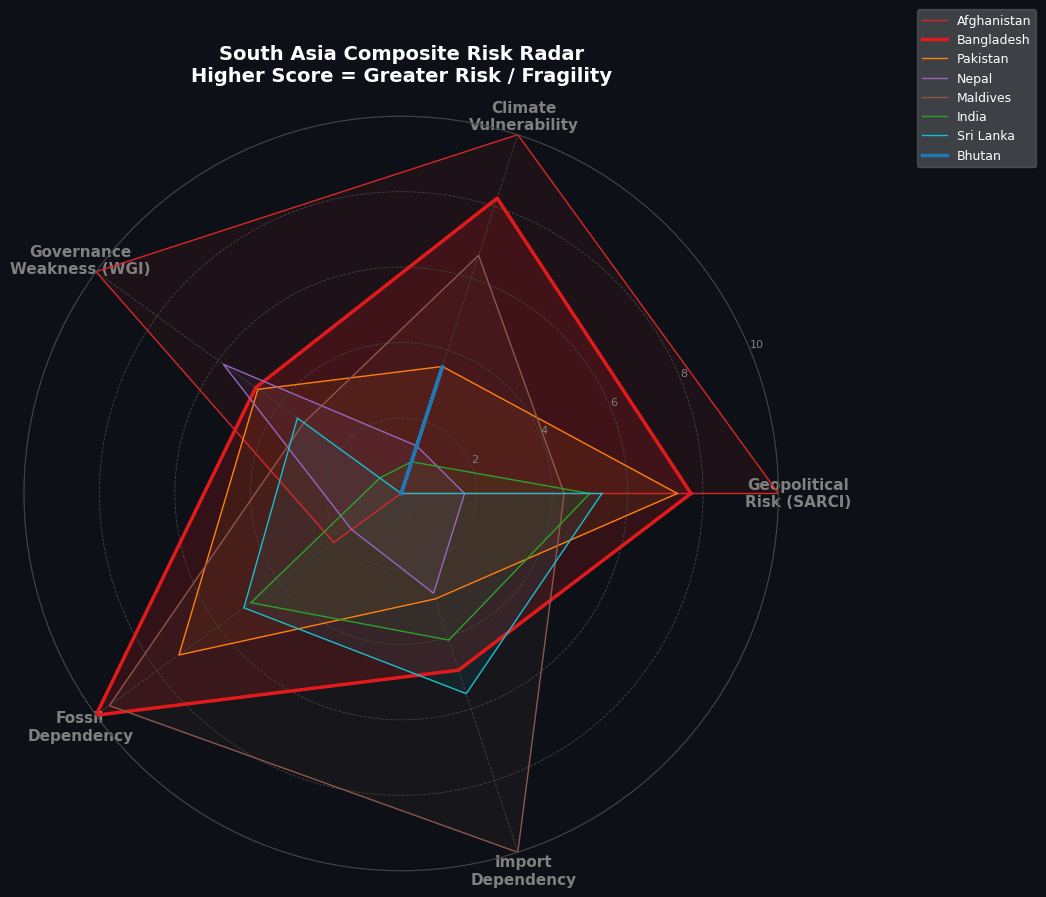

Saved: chart6_radar.png


In [24]:
# ── DATA ──────────────────────────────────────────────────────────────────
data = {
    'Country':        ['Afghanistan','Bangladesh','Pakistan','Nepal','Maldives','India','Sri Lanka','Bhutan'],
    'SARCI':          [3.75, 3.17, 3.08, 1.67, 2.33, 2.50, 2.58, 1.25],
    'ND_Vulnerability':[0.588, 0.568, 0.515, 0.490, 0.550, 0.485, 0.475, 0.515],
    'WGI':            [13.74, 39.31, 39.67, 34.14, 47.04, 59.21, 46.00, 62.63],
    'RE_Pct':         [78.23, 1.51, 28.28, 83.98, 5.82, 51.50, 49.24, 100.00],
    'Energy_Imports': [0, 44.31, 26.43, 25.0, 90.0, 36.77, 50.21, 0]
}
df = pd.DataFrame(data)

# ── NORMALISE TO 0–10 ──────────────────────────────────────────────────────
# For risk radar: higher score = MORE DANGEROUS
# SARCI: higher = more risk ✓ (keep as is)
# ND_Vulnerability: higher = more risk ✓ (keep as is)
# WGI: higher = better governance = LESS risk → invert
# RE_Pct: higher = more renewable = LESS risk → invert
# Energy_Imports: higher = more dependent = more risk ✓ (keep as is)

scaler = MinMaxScaler(feature_range=(0, 10))

df['SARCI_n']       = scaler.fit_transform(df[['SARCI']])
df['NDG_n']         = scaler.fit_transform(df[['ND_Vulnerability']])
df['WGI_n']         = 10 - scaler.fit_transform(df[['WGI']])          # inverted
df['RE_n']          = 10 - scaler.fit_transform(df[['RE_Pct']])        # inverted
df['EI_n']          = scaler.fit_transform(df[['Energy_Imports']])

categories = ['Geopolitical\nRisk (SARCI)', 'Climate\nVulnerability',
              'Governance\nWeakness (WGI)', 'Fossil\nDependency', 'Import\nDependency']
N = len(categories)

# ── COLOURS ───────────────────────────────────────────────────────────────
colors = {
    'Afghanistan': '#d62728',
    'Bangladesh':  '#e31a1c',
    'Pakistan':    '#ff7f0e',
    'Nepal':       '#9467bd',
    'Maldives':    '#8c564b',
    'India':       '#2ca02c',
    'Sri Lanka':   '#17becf',
    'Bhutan':      '#1f77b4'
}
# Make Bangladesh and Bhutan stand out
highlight = {'Bangladesh': (2.5, '#e31a1c'), 'Bhutan': (2.5, '#1f77b4')}

# ── PLOT ──────────────────────────────────────────────────────────────────
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

for _, row in df.iterrows():
    country = row['Country']
    values = [row['SARCI_n'], row['NDG_n'], row['WGI_n'], row['RE_n'], row['EI_n']]
    values += values[:1]

    lw = highlight.get(country, (1.0, colors[country]))[0]
    color = colors[country]
    alpha = 0.85 if country in highlight else 0.45

    ax.plot(angles, values, linewidth=lw, color=color, label=country)
    ax.fill(angles, values, color=color, alpha=0.08 if country not in highlight else 0.18)

# Grid styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, color='white', fontweight='bold')
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2','4','6','8','10'], color='grey', size=8)
ax.set_ylim(0, 10)
ax.tick_params(colors='grey')
ax.spines['polar'].set_color('#444444')
ax.grid(color='#444444', linestyle='--', linewidth=0.6)

# Title + legend
plt.title('South Asia Composite Risk Radar\nHigher Score = Greater Risk / Fragility',
          size=14, color='white', fontweight='bold', pad=25)
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                   fontsize=9, framealpha=0.2, labelcolor='white')

plt.tight_layout()
plt.savefig('chart6_radar.png', dpi=180, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Saved: chart6_radar.png")

In [29]:
# ── LOAD ACLED DATA ───────────────────────────────────────────────────────
events_df = pd.read_excel('number_of_political_violence_events_by_country-year_as-of-03Apr2026.xlsx')
fatal_df  = pd.read_excel('number_of_reported_fatalities_by_country-year_as-of-03Apr2026.xlsx')

# Filter to South Asia only
south_asia = ['Afghanistan', 'Bangladesh', 'India', 'Pakistan', 'Sri Lanka', 'Bhutan', 'Nepal', 'Maldives']

events_filtered = events_df[events_df['Country'].isin(south_asia)].copy()
fatal_filtered  = fatal_df[fatal_df['Country'].isin(south_asia)].copy()

# Melt to long format — adjust column names if yours differ
# Typical ACLED export has Country + Year columns like '2020', '2021' etc.
events_long = events_filtered.melt(id_vars='Country', var_name='Year', value_name='Events')
fatal_long  = fatal_filtered.melt(id_vars='Country', var_name='Year', value_name='Fatalities')

events_long['Year'] = pd.to_numeric(events_long['Year'], errors='coerce')
fatal_long['Year']  = pd.to_numeric(fatal_long['Year'], errors='coerce')

events_long = events_long.dropna(subset=['Year'])
fatal_long  = fatal_long.dropna(subset=['Year'])

# Filter years 2020–2025
events_long = events_long[events_long['Year'] >= 2020]
fatal_long  = fatal_long[fatal_long['Year'] >= 2020]

# ── PLOT ──────────────────────────────────────────────────────────────────
colors_sa = {
    'Afghanistan': '#d62728', 'Bangladesh': '#e31a1c',
    'India': '#2ca02c', 'Pakistan': '#ff7f0e',
    'Sri Lanka': '#17becf', 'Bhutan': '#1f77b4',
    'Nepal': '#9467bd', 'Maldives': '#8c564b'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Left: Events
for country in south_asia:
    d = events_long[events_long['Country'] == country]
    lw = 2.5 if country in ['Afghanistan', 'Bangladesh', 'Pakistan'] else 1.2
    alpha = 1.0 if country in ['Afghanistan', 'Bangladesh', 'Pakistan'] else 0.5
    ax1.plot(d['Year'], d['Events'], marker='o', markersize=4,
             label=country, color=colors_sa[country], linewidth=lw, alpha=alpha)

ax1.set_title('Political Violence Events (2020–2025)', color='white', fontweight='bold', size=12)
ax1.set_xlabel('Year', color='white'); ax1.set_ylabel('Number of Events', color='white')
ax1.legend(fontsize=8, framealpha=0.1, labelcolor='white')
ax1.yaxis.label.set_color('white'); ax1.xaxis.label.set_color('white')

# Right: Fatalities
for country in south_asia:
    d = fatal_long[fatal_long['Country'] == country]
    lw = 2.5 if country in ['Afghanistan', 'Pakistan'] else 1.2
    alpha = 1.0 if country in ['Afghanistan', 'Bangladesh', 'Pakistan'] else 0.5
    ax2.plot(d['Year'], d['Fatalities'], marker='o', markersize=4,
             label=country, color=colors_sa[country], linewidth=lw, alpha=alpha)

ax2.set_title('Reported Fatalities (2020–2025)', color='white', fontweight='bold', size=12)
ax2.set_xlabel('Year', color='white'); ax2.set_ylabel('Fatalities', color='white')
ax2.legend(fontsize=8, framealpha=0.1, labelcolor='white')

fig.suptitle('South Asia: Political Violence & Stability (ACLED Data)',
             fontsize=15, color='white', fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart5_acled.png', dpi=180, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: chart5_acled.png")

KeyError: 'Country'

In [26]:
events_df = pd.read_excel('number_of_political_violence_events_by_country-year_as-of-03Apr2026.xlsx')
fatal_df  = pd.read_excel('number_of_reported_fatalities_by_country-year_as-of-03Apr2026.xlsx')

print("Events columns:", events_df.columns.tolist())
print("Fatalities columns:", fatal_df.columns.tolist())
print("\nFirst 3 rows of events:")
print(events_df.head(3))

Events columns: ['COUNTRY', 'YEAR', 'EVENTS']
Fatalities columns: ['COUNTRY', 'YEAR', 'FATALITIES']

First 3 rows of events:
       COUNTRY  YEAR  EVENTS
0  Afghanistan  2017   12582
1  Afghanistan  2018   13664
2  Afghanistan  2019   13612


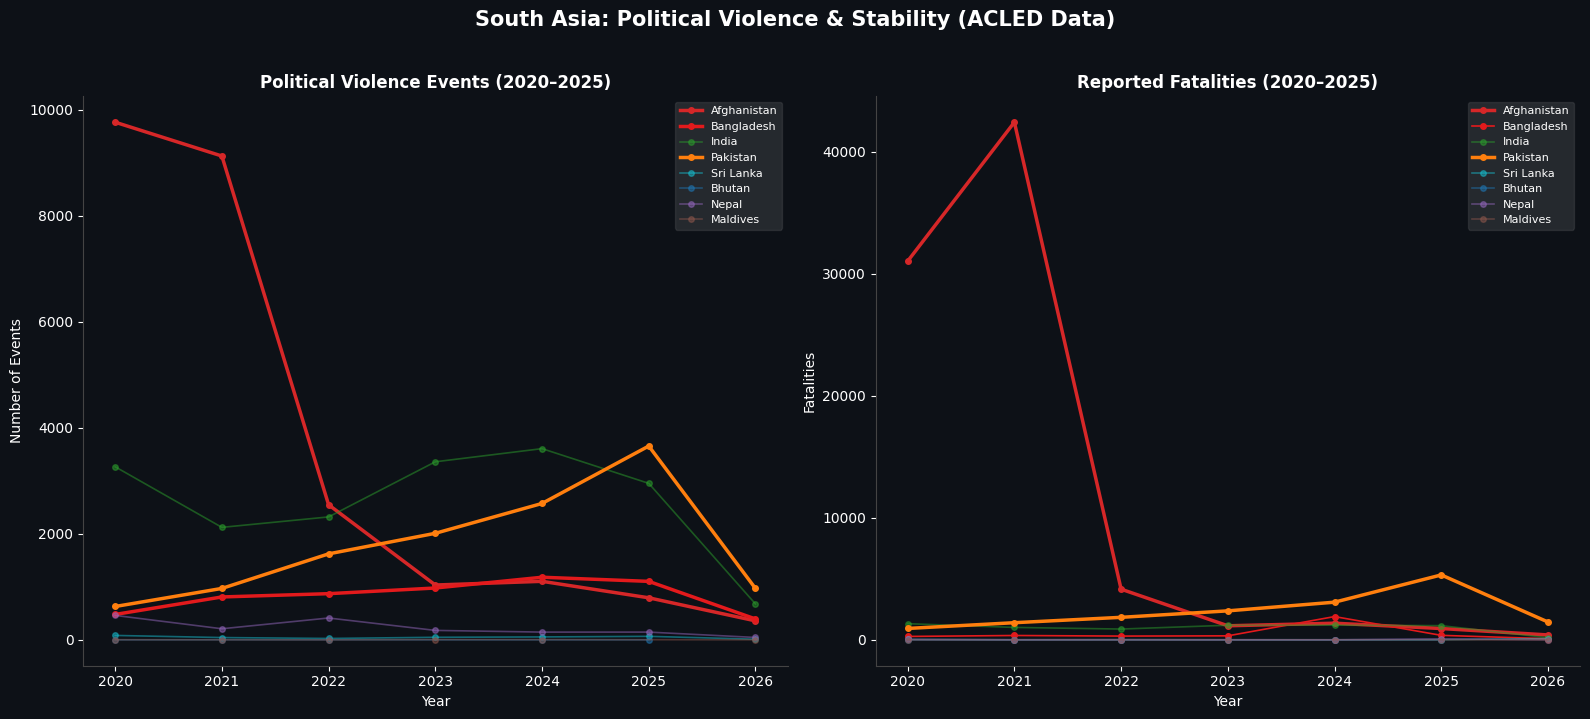

Saved: chart5_acled.png


In [27]:
south_asia = ['Afghanistan', 'Bangladesh', 'India', 'Pakistan', 'Sri Lanka', 'Bhutan', 'Nepal', 'Maldives']

events_filtered = events_df[events_df['COUNTRY'].isin(south_asia)].copy()
fatal_filtered  = fatal_df[fatal_df['COUNTRY'].isin(south_asia)].copy()

# Filter years 2020–2025
events_filtered = events_filtered[events_filtered['YEAR'] >= 2020]
fatal_filtered  = fatal_filtered[fatal_filtered['YEAR'] >= 2020]

colors_sa = {
    'Afghanistan': '#d62728', 'Bangladesh': '#e31a1c',
    'India': '#2ca02c', 'Pakistan': '#ff7f0e',
    'Sri Lanka': '#17becf', 'Bhutan': '#1f77b4',
    'Nepal': '#9467bd', 'Maldives': '#8c564b'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Left: Events
for country in south_asia:
    d = events_filtered[events_filtered['COUNTRY'] == country]
    lw = 2.5 if country in ['Afghanistan', 'Bangladesh', 'Pakistan'] else 1.2
    alpha = 1.0 if country in ['Afghanistan', 'Bangladesh', 'Pakistan'] else 0.5
    ax1.plot(d['YEAR'], d['EVENTS'], marker='o', markersize=4,
             label=country, color=colors_sa[country], linewidth=lw, alpha=alpha)

ax1.set_title('Political Violence Events (2020–2025)', color='white', fontweight='bold', size=12)
ax1.set_xlabel('Year', color='white')
ax1.set_ylabel('Number of Events', color='white')
ax1.legend(fontsize=8, framealpha=0.1, labelcolor='white')

# Right: Fatalities
for country in south_asia:
    d = fatal_filtered[fatal_filtered['COUNTRY'] == country]
    lw = 2.5 if country in ['Afghanistan', 'Pakistan'] else 1.2
    alpha = 1.0 if country in ['Afghanistan', 'Bangladesh', 'Pakistan'] else 0.5
    ax2.plot(d['YEAR'], d['FATALITIES'], marker='o', markersize=4,
             label=country, color=colors_sa[country], linewidth=lw, alpha=alpha)

ax2.set_title('Reported Fatalities (2020–2025)', color='white', fontweight='bold', size=12)
ax2.set_xlabel('Year', color='white')
ax2.set_ylabel('Fatalities', color='white')
ax2.legend(fontsize=8, framealpha=0.1, labelcolor='white')

fig.suptitle('South Asia: Political Violence & Stability (ACLED Data)',
             fontsize=15, color='white', fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart5_acled.png', dpi=180, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: chart5_acled.png")

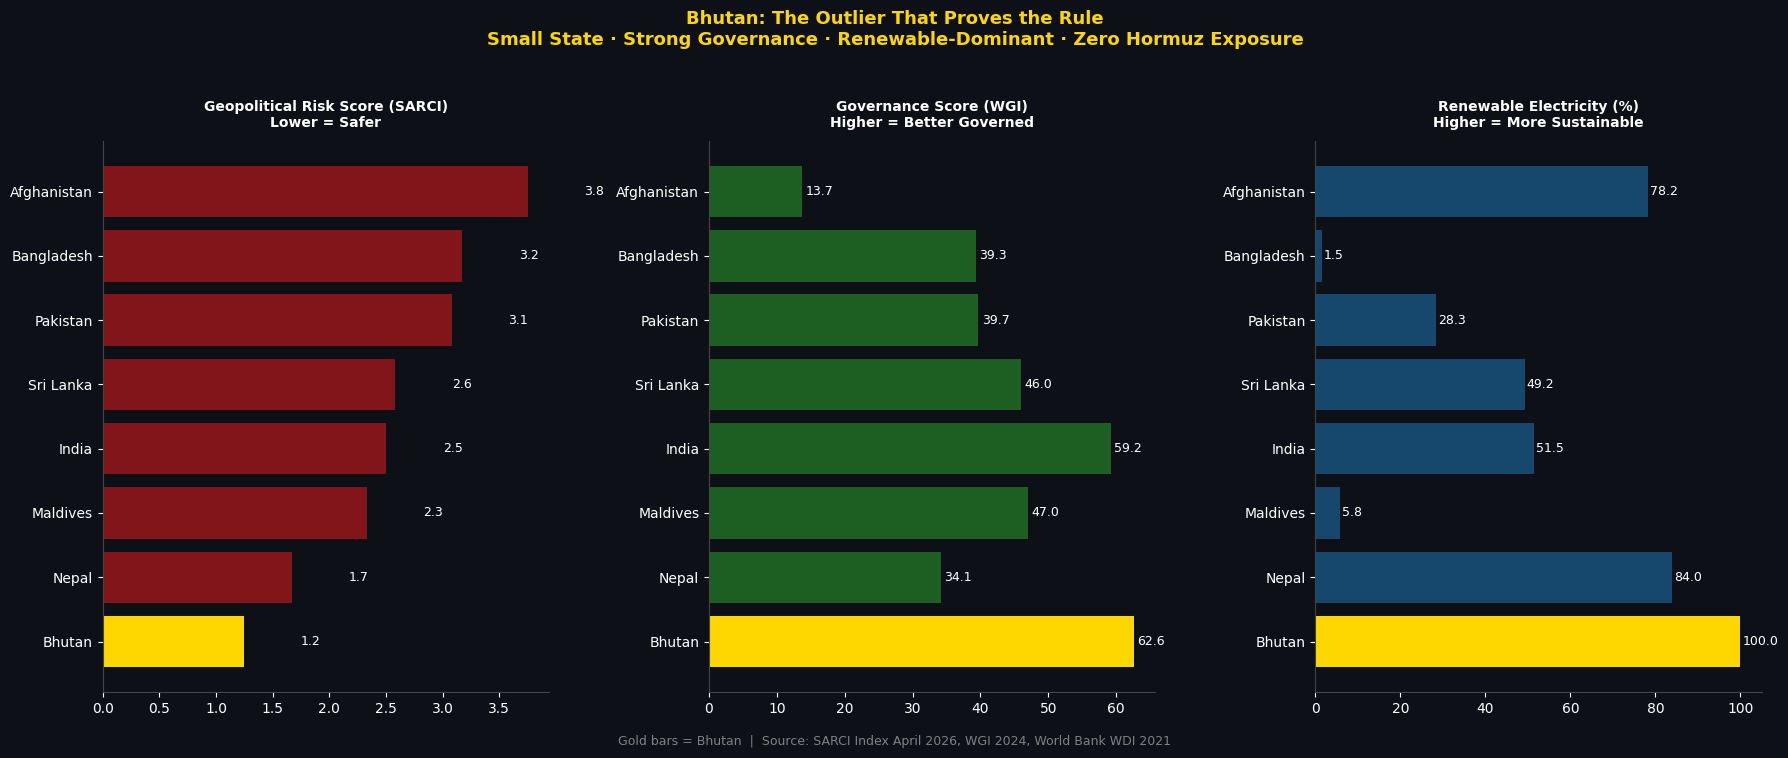

Saved: chart7_bhutan.png


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

countries = ['Afghanistan','Bangladesh','Pakistan','Nepal','Maldives','India','Sri Lanka','Bhutan']

sarci  = [3.75, 3.17, 3.08, 1.67, 2.33, 2.50, 2.58, 1.25]
wgi    = [13.74, 39.31, 39.67, 34.14, 47.04, 59.21, 46.00, 62.63]
re_pct = [78.23, 1.51, 28.28, 83.98, 5.82, 51.50, 49.24, 100.00]

df = pd.DataFrame({'Country': countries, 'SARCI': sarci, 'WGI': wgi, 'RE_Pct': re_pct})
df = df.sort_values('SARCI', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')

metrics = [
    ('SARCI', 'Geopolitical Risk Score (SARCI)', 'Lower = Safer', '#e31a1c'),
    ('WGI',   'Governance Score (WGI)', 'Higher = Better Governed', '#2ca02c'),
    ('RE_Pct','Renewable Electricity (%)', 'Higher = More Sustainable', '#1f77b4'),
]

for ax, (col, title, subtitle, base_color) in zip(axes, metrics):
    colors = ['#FFD700' if c == 'Bhutan' else base_color for c in df['Country']]
    alpha  = [1.0 if c == 'Bhutan' else 0.55 for c in df['Country']]

    bars = ax.barh(df['Country'], df[col], color=colors)
    for bar, a in zip(bars, alpha):
        bar.set_alpha(a)

    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white', labelsize=10)
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f'{title}\n{subtitle}', color='white', fontsize=10, fontweight='bold', pad=10)
    ax.xaxis.label.set_color('white')

    # Add value labels
    for bar, val in zip(bars, df[col]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', color='white', fontsize=9)

fig.suptitle('Bhutan: The Outlier That Proves the Rule\nSmall State · Strong Governance · Renewable-Dominant · Zero Hormuz Exposure',
             fontsize=13, color='#FFD700', fontweight='bold', y=1.03)

# Annotation
fig.text(0.5, -0.02,
         'Gold bars = Bhutan  |  Source: SARCI Index April 2026, WGI 2024, World Bank WDI 2021',
         ha='center', color='grey', fontsize=9)

plt.tight_layout()
plt.savefig('chart7_bhutan.png', dpi=180, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: chart7_bhutan.png")